# Вторая лабораторная работа: multi-task

## Импорты и константы

In [79]:
import gc
import random
import warnings
from datetime import datetime
from pathlib import Path
from pprint import pp

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from tqdm import tqdm

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [80]:
RANDOM_SEED = 42
torch.manual_seed = RANDOM_SEED

In [81]:
AUDIO_DATASET = Path("data/MELD_audio/archive/dev")
METADATA = Path("data/MELD_audio/dev.csv")

In [82]:
FRIENDS_NAMES = ['Phoebe', 'Monica', 'Ross', 'Chandler', 'Joey', 'Rachel']

In [83]:
metadata_df = pd.read_csv(METADATA, index_col="Sr No.")
# Ограничиваем только 6 главными героями
metadata_df = metadata_df[metadata_df["Speaker"].isin(FRIENDS_NAMES)]

In [84]:
SENTIMENT_CATEGORIES = list(metadata_df["Sentiment"].unique())
SENTIMENT_CATEGORIES

['negative', 'neutral', 'positive']

In [85]:
metadata_df.head()

,Utterance,Speaker,Emotion,Sentiment,Dialogue_ID,Utterance_ID,Season,Episode,StartTime,EndTime
Sr No.,,,,,,,,,,
1,"Oh my God, hes lost it. Hes totally lost it.",Phoebe,sadness,negative,0,0,4,7,"00:20:57,256","00:21:00,049"
2,What?,Monica,surprise,negative,0,1,4,7,"00:21:01,927","00:21:03,261"
3,"Or! Or, we could go to the bank, close our acc...",Ross,neutral,neutral,1,0,4,4,"00:12:24,660","00:12:30,915"
4,Youre a genius!,Chandler,joy,positive,1,1,4,4,"00:12:32,334","00:12:33,960"
5,"Aww, man, now we wont be bank buddies!",Joey,sadness,negative,1,2,4,4,"00:12:34,211","00:12:37,505"


In [86]:
color_palette = dict.fromkeys([
    "maroon",
    "saddlebrown",
    "darkolivegreen",
    "olive",
    "burlywood",
    "antiquewhite",
], 0)

In [87]:
def choose_color(colors, first_n=2):
    color_n = sorted(colors, key=colors.get)[:first_n]
    color = random.choice(color_n)
    colors[color] += 1
    return color

In [88]:
PLT_FIG_SIZE = (12,6)

In [89]:
SR = 16000

In [90]:
EMBEDDINGS_DIR_PATH = Path("data/embeddings")
EMBEDDINGS_DIR_PATH.mkdir(exist_ok=True)

In [ ]:
EMBEDDINGS_PATH = EMBEDDINGS_DIR_PATH / "librosa.pt"

In [141]:
MODEL_DIR_PATH = Path("data/models")
MODEL_DIR_PATH.mkdir(exist_ok=True)

## Чистим метадату

In [92]:
def join_dialogue_utterance(dialogue_id, utterance_id):
    return f"dia{dialogue_id}_utt{utterance_id}.flac"


audio_names = []
for row in metadata_df.iterrows():
    values = row[1]
    audio_name = join_dialogue_utterance(
        values["Dialogue_ID"], values["Utterance_ID"]
    )
    if Path(AUDIO_DATASET / audio_name).exists():
        audio_names.append(AUDIO_DATASET / audio_name)
    else:
        audio_names.append(np.nan)

metadata_df["audio_path"] = audio_names
metadata_df = metadata_df.dropna()

In [93]:
metadata_df

,Utterance,Speaker,Emotion,Sentiment,Dialogue_ID,Utterance_ID,Season,Episode,StartTime,EndTime,audio_path
Sr No.,,,,,,,,,,,
1,"Oh my God, hes lost it. Hes totally lost it.",Phoebe,sadness,negative,0,0,4,7,"00:20:57,256","00:21:00,049",data/MELD_audio/archive/dev/dia0_utt0.flac
2,What?,Monica,surprise,negative,0,1,4,7,"00:21:01,927","00:21:03,261",data/MELD_audio/archive/dev/dia0_utt1.flac
3,"Or! Or, we could go to the bank, close our acc...",Ross,neutral,neutral,1,0,4,4,"00:12:24,660","00:12:30,915",data/MELD_audio/archive/dev/dia1_utt0.flac
4,Youre a genius!,Chandler,joy,positive,1,1,4,4,"00:12:32,334","00:12:33,960",data/MELD_audio/archive/dev/dia1_utt1.flac
5,"Aww, man, now we wont be bank buddies!",Joey,sadness,negative,1,2,4,4,"00:12:34,211","00:12:37,505",data/MELD_audio/archive/dev/dia1_utt2.flac
...,...,...,...,...,...,...,...,...,...,...,...
1174,No.,Monica,sadness,negative,113,9,6,2,"00:19:28,792","00:19:29,876",data/MELD_audio/archive/dev/dia113_utt9.flac
1175,What? Oh my God! Im gonna miss you so much!,Rachel,sadness,negative,113,10,6,2,"00:19:33,213","00:19:35,965",data/MELD_audio/archive/dev/dia113_utt10.flac
1176,Im gonna miss you!,Monica,sadness,negative,113,11,6,2,"00:19:36,175","00:19:37,967",data/MELD_audio/archive/dev/dia113_utt11.flac


## EDA

In [94]:
print(f"Всего в датасете {len(metadata_df)} реплик")

Всего в датасете 952 реплик


In [95]:
speaker_utterances_amount = {}
for speaker in metadata_df["Speaker"].unique():
    speaker_utterances_amount[speaker] = [
        len(metadata_df[metadata_df["Speaker"] == speaker])
    ]

print("Реплик у каждого героя:")
pp(speaker_utterances_amount)

Реплик у каждого героя:
{'Phoebe': [184],
 'Monica': [137],
 'Ross': [217],
 'Chandler': [101],
 'Joey': [149],
 'Rachel': [164]}


In [96]:
unique_emotions = metadata_df["Emotion"].unique()
print(f"Всего в датасете {len(unique_emotions)} эмоций: {unique_emotions}")

Всего в датасете 7 эмоций: ['sadness' 'surprise' 'neutral' 'joy' 'anger' 'disgust' 'fear']


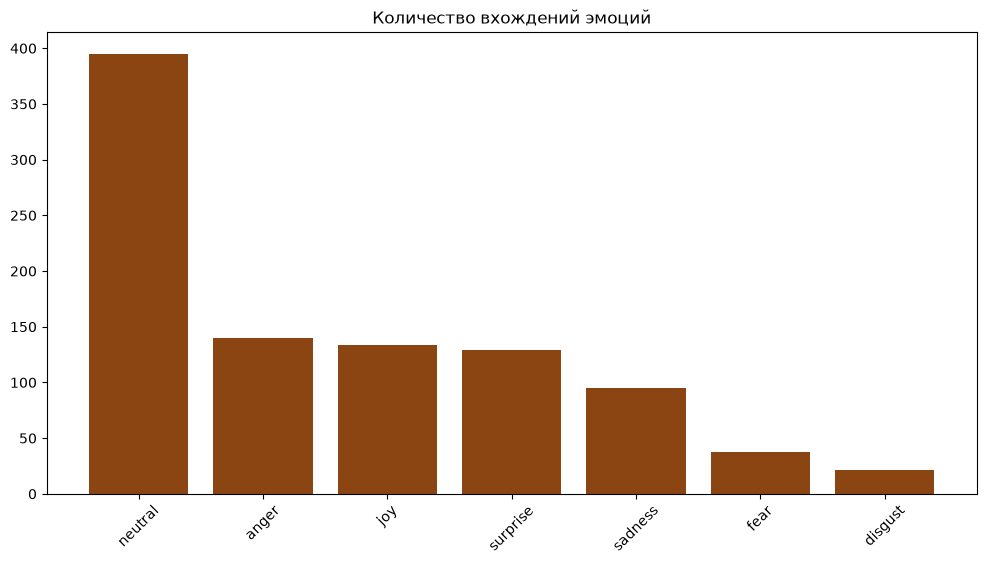

In [97]:
emotion_counts = metadata_df["Emotion"].value_counts()

plt.figure(figsize=PLT_FIG_SIZE)
plt.title("Количество вхождений эмоций")
plt.bar(
    emotion_counts.index,
    emotion_counts.to_numpy(dtype=int),
    color=choose_color(color_palette)
)
plt.xticks(rotation=45)
plt.show()

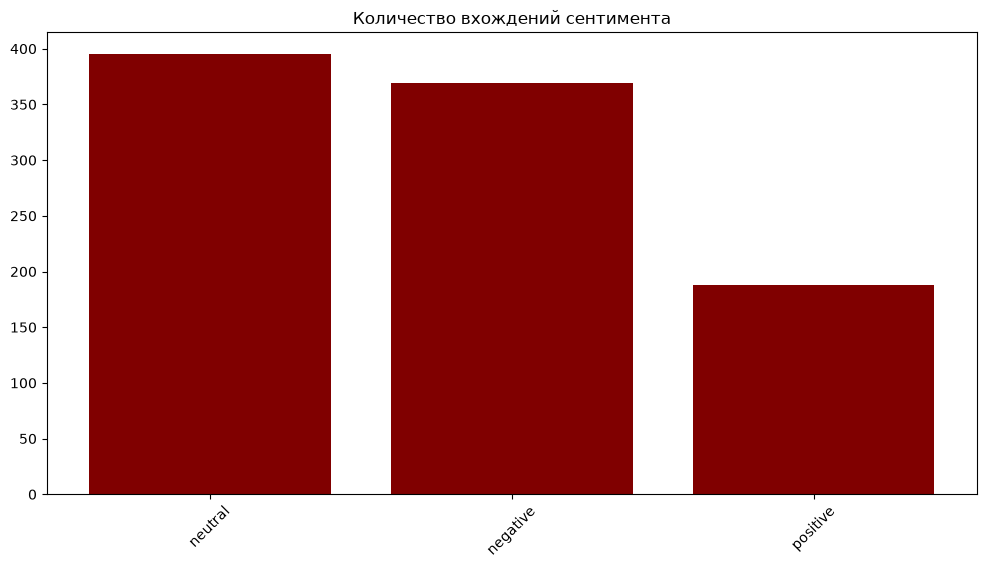

In [98]:
sentiment_counts = metadata_df["Sentiment"].value_counts()

plt.figure(figsize=PLT_FIG_SIZE)
plt.title("Количество вхождений сентимента")
plt.bar(
    sentiment_counts.index,
    sentiment_counts.to_numpy(dtype=int),
    color=choose_color(color_palette)
)
plt.xticks(rotation=45)
plt.show()

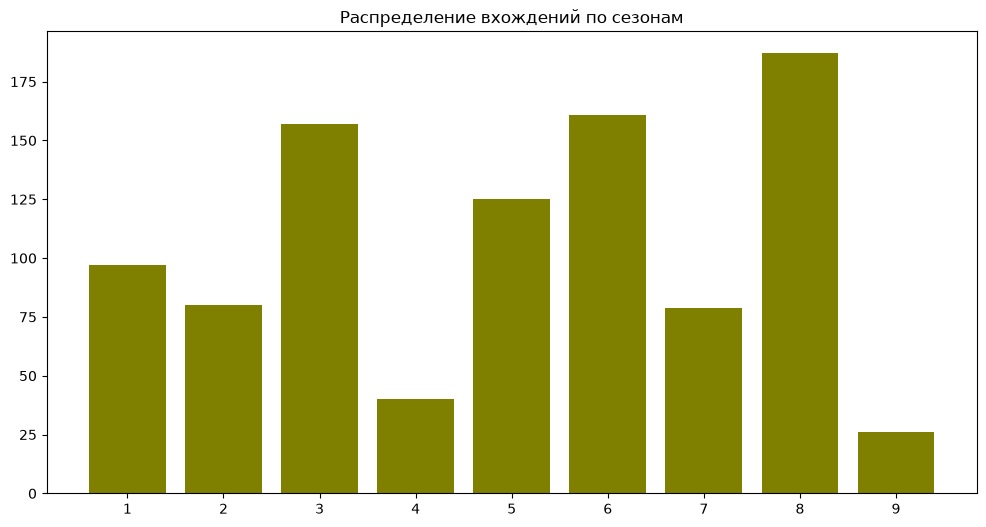

In [99]:
season_counts = metadata_df["Season"].value_counts()

plt.figure(figsize=PLT_FIG_SIZE)
plt.title("Распределение вхождений по сезонам")
plt.bar(
    season_counts.index,
    season_counts.to_numpy(dtype=int),
    color=choose_color(color_palette)
)
plt.xticks(season_counts.index)
plt.show()

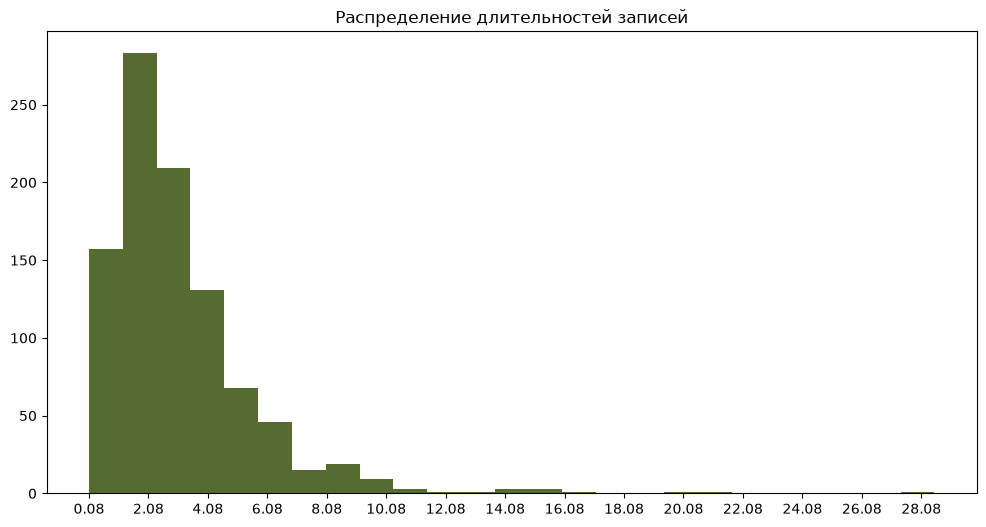

In [100]:
def str_to_dt(str_inpt):
    format = "%H:%M:%S,%f"
    datetime_str = datetime.strptime(str_inpt, format)  # noqa: DTZ007
    return datetime_str

utterance_start = metadata_df["StartTime"].apply(str_to_dt)
utterance_end = metadata_df["EndTime"].apply(str_to_dt)
utterance_dur = np.array([
    x.total_seconds()
    for x in [
        end - start for start, end in zip(utterance_start, utterance_end)
    ]
])

plt.figure(figsize=PLT_FIG_SIZE)
plt.title("Распределение длительностей записей")
plt.hist(
    utterance_dur,
    color=choose_color(color_palette),
    bins=25
)
plt.xticks(np.arange(min(utterance_dur), max(utterance_dur), 2))
plt.show()

## Извлекаем признаки

In [101]:
def extract_librosa_features(audio_path, sr=SR, n_mfcc=40, chunk_audio=True):

    def get_features(audio):
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(audio)
        rms = librosa.feature.rms(y=audio)

        features = np.concatenate([
            mfcc.mean(axis=1),
            mfcc.std(axis=1),
            chroma.mean(axis=1),
            chroma.std(axis=1),
            spectral_centroid.mean(axis=1),
            spectral_centroid.std(axis=1),
            spectral_bandwidth.mean(axis=1),
            spectral_bandwidth.std(axis=1),
            spectral_rolloff.mean(axis=1),
            spectral_rolloff.std(axis=1),
            zero_crossing_rate.mean(axis=1),
            zero_crossing_rate.std(axis=1),
            rms.mean(axis=1),
            rms.std(axis=1),
        ])
        return torch.from_numpy(features).float()

    audio, _ = librosa.load(audio_path, sr=sr, mono=True)

    if chunk_audio:
        window_length = int(sr * 0.5)
        features = []
        for idx in range(0, len(audio), window_length):
            window = audio[idx : idx + window_length]
            features.append(get_features(window))
        return torch.stack(features).mean(dim=0)

    return get_features(audio)

In [102]:
if not Path.exists(EMBEDDINGS_PATH):
    embs = []
    for idx in tqdm(range(len(metadata_df))):
        audio_path = metadata_df["audio_path"].iloc[idx]
        batch_embs = extract_librosa_features(audio_path, chunk_audio=True)
        embs.append(batch_embs)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    embs = torch.stack(embs)
    torch.save(embs, EMBEDDINGS_PATH)

else:
    embs = torch.load(EMBEDDINGS_PATH)

## Отдельно классифицируем персонажа

In [103]:
embs = torch.load(EMBEDDINGS_PATH)
librosa_emb_length = embs.shape[-1]

In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    embs, 
    metadata_df["Speaker"].to_list(),
    test_size=0.2,
    random_state=RANDOM_SEED,
)

In [105]:
X_train.shape

torch.Size([761, 114])

In [106]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [107]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

In [108]:
class SpeakerIdentificationModel(nn.Module):
    def __init__(self, emb_length):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(emb_length, emb_length // 2),
            nn.ReLU(),

            nn.Linear(emb_length // 2, len(FRIENDS_NAMES)),
        )

    def forward(self, emb):
        logits = self.classifier(emb)
        return logits

In [109]:
model = SpeakerIdentificationModel(librosa_emb_length)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [110]:
name_to_id = {
    name: i
    for i, name in enumerate(FRIENDS_NAMES)
}

y_train = torch.tensor(
    [name_to_id[name] for name in y_train],
    dtype=torch.long
)
y_test = torch.tensor(
    [name_to_id[name] for name in y_test],
    dtype=torch.long
)

In [111]:
loss_epochs = []
n_epochs = 10000
for epoch in tqdm(range(n_epochs)):
    optimizer.zero_grad()

    logits = model(X_train)

    loss = criterion(
        logits,
        y_train
    )

    loss.backward()
    optimizer.step()

    loss_epochs.append(loss.item())

100%|██████████| 10000/10000 [00:10<00:00, 990.96it/s]


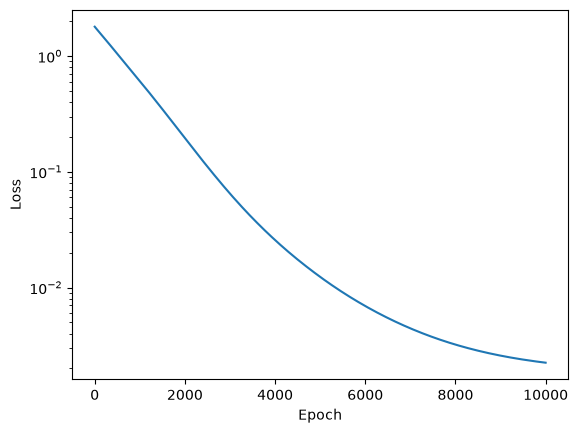

In [112]:
plt.plot(loss_epochs)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [113]:
with torch.inference_mode():
    logits = model(X_test)
preds = torch.argmax(logits, dim=1)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.58      0.48      0.53        31
           1       0.41      0.57      0.48        28
           2       0.84      0.86      0.85        50
           3       0.40      0.53      0.46        15
           4       0.78      0.74      0.76        34
           5       0.39      0.27      0.32        33

    accuracy                           0.61       191
   macro avg       0.57      0.58      0.57       191
weighted avg       0.61      0.61      0.60       191



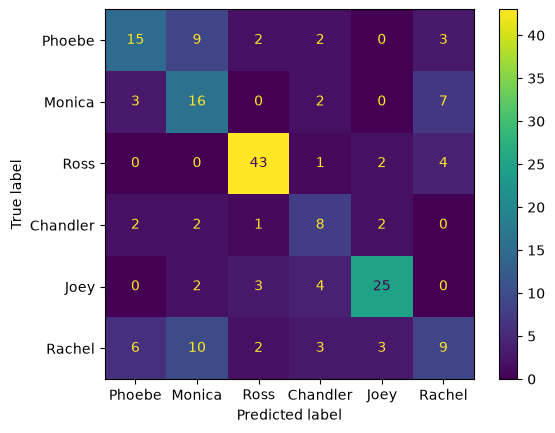

In [114]:
true_names = [
    FRIENDS_NAMES[y]
    for y in y_test
]

pred_names = [
    FRIENDS_NAMES[p]
    for p in preds
]

ConfusionMatrixDisplay.from_predictions(
    true_names,
    pred_names,
    labels=FRIENDS_NAMES,
)
plt.show()

## Отдельно определяем сентимент

In [115]:
embs = torch.load(EMBEDDINGS_PATH)
librosa_emb_length = embs.shape[-1]

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    embs, 
    metadata_df["Sentiment"].to_list(),
    test_size=0.2,
    random_state=RANDOM_SEED,
)

In [117]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [118]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

In [119]:
class SpeakerIdentificationModel(nn.Module):
    def __init__(self, emb_length):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(emb_length, emb_length // 2),
            nn.ReLU(),

            nn.Linear(emb_length // 2, emb_length // 4),
            nn.ReLU(),

            nn.Linear(emb_length // 4, len(SENTIMENT_CATEGORIES)),
        )

    def forward(self, emb):
        logits = self.classifier(emb)
        return logits

In [120]:
model = SpeakerIdentificationModel(librosa_emb_length)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [121]:
category_to_id = {
    category: i
    for i, category in enumerate(SENTIMENT_CATEGORIES)
}

y_train = torch.tensor(
    [category_to_id[category] for category in y_train],
    dtype=torch.long
)
y_test = torch.tensor(
    [category_to_id[category] for category in y_test],
    dtype=torch.long
)

In [122]:
loss_epochs = []
n_epochs = 15000
for epoch in tqdm(range(n_epochs)):
    optimizer.zero_grad()

    logits = model(X_train)

    loss = criterion(
        logits,
        y_train
    )

    loss.backward()
    optimizer.step()

    loss_epochs.append(loss.item())

  0%|          | 0/15000 [00:00<?, ?it/s]

100%|██████████| 15000/15000 [00:14<00:00, 1008.77it/s]


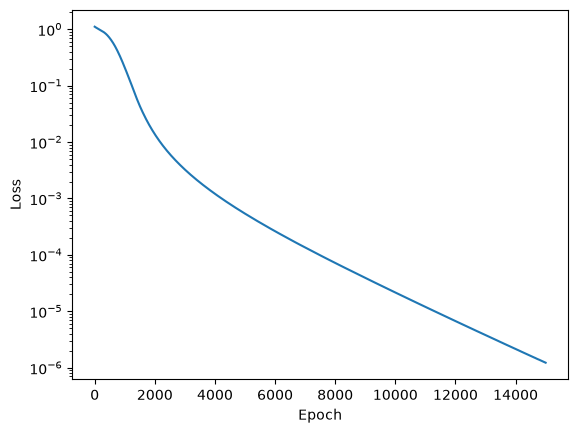

In [123]:
plt.plot(loss_epochs)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [124]:
with torch.inference_mode():
    logits = model(X_test)
preds = torch.argmax(logits, dim=1)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.54      0.51      0.53        70
           1       0.51      0.61      0.56        80
           2       0.21      0.15      0.17        41

    accuracy                           0.48       191
   macro avg       0.42      0.42      0.42       191
weighted avg       0.46      0.48      0.46       191



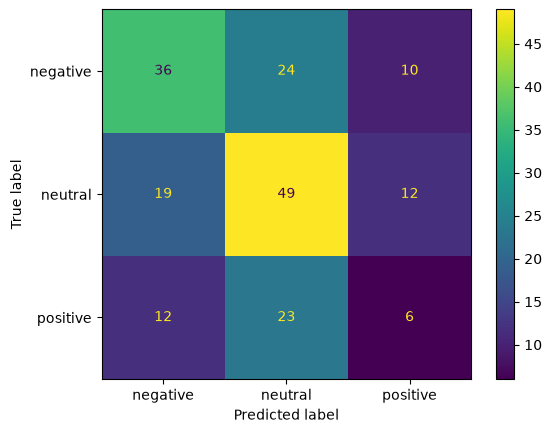

In [125]:
true_names = [
    SENTIMENT_CATEGORIES[y]
    for y in y_test
]

pred_names = [
    SENTIMENT_CATEGORIES[p]
    for p in preds
]

ConfusionMatrixDisplay.from_predictions(
    true_names,
    pred_names,
    labels=SENTIMENT_CATEGORIES,
)
plt.show()

## Multi-task

In [126]:
embs = torch.load(EMBEDDINGS_PATH)
librosa_emb_length = embs.shape[-1]

In [127]:
X_train, X_test, y_1_train, y_1_test, y_2_train, y_2_test = train_test_split(
    embs, 
    metadata_df["Speaker"].to_list(),
    metadata_df["Sentiment"].to_list(),
    test_size=0.2,
    random_state=RANDOM_SEED,
)

In [128]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [129]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

In [140]:
class MultiTask(nn.Module):
    def __init__(self, emb_length):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(emb_length, 256),
            nn.ReLU()
        )
        self.speaker_head = nn.Sequential(
            nn.Linear(256, len(FRIENDS_NAMES))
        )
        self.sentiment_head = nn.Sequential(
            nn.Linear(256, len(SENTIMENT_CATEGORIES))
        )

    def forward(self, emb):
        features = self.encoder(emb)

        logits = [
            self.speaker_head(features),
            self.sentiment_head(features)
        ]
        return logits

In [131]:
model = MultiTask(librosa_emb_length)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [132]:
name_to_id = {
    name: i
    for i, name in enumerate(FRIENDS_NAMES)
}
y_1_train = torch.tensor(
    [name_to_id[name] for name in y_1_train],
    dtype=torch.long
)
y_1_test = torch.tensor(
    [name_to_id[name] for name in y_1_test],
    dtype=torch.long
)


In [133]:
category_to_id = {
    category: i
    for i, category in enumerate(SENTIMENT_CATEGORIES)
}
y_2_train = torch.tensor(
    [category_to_id[category] for category in y_2_train],
    dtype=torch.long
)
y_2_test = torch.tensor(
    [category_to_id[category] for category in y_2_test],
    dtype=torch.long
)

In [134]:
loss_epochs = []
n_epochs = 15000
for epoch in tqdm(range(n_epochs)):
    optimizer.zero_grad()

    out_1, out_2 = model(X_train)

    loss_1 = criterion(out_1, y_1_train)
    loss_2 = criterion(out_2, y_2_train)

    loss = loss_1 + loss_2

    loss.backward()
    optimizer.step()

    loss_epochs.append(loss.item())

100%|██████████| 15000/15000 [00:26<00:00, 559.50it/s]


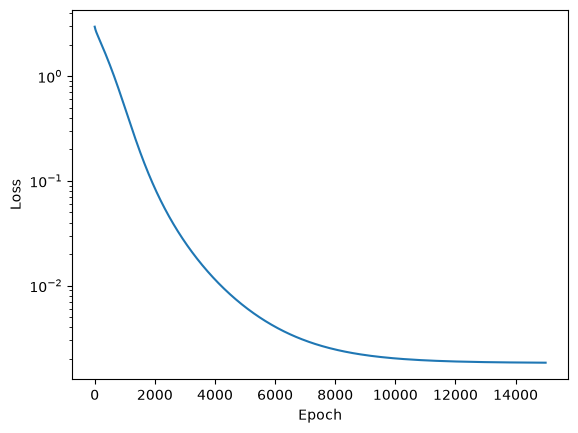

In [135]:
plt.plot(loss_epochs)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [136]:
with torch.inference_mode():
    out_1, out_2 = model(X_test)
character = torch.argmax(out_1, dim=1)
sentiment = torch.argmax(out_2, dim=1)

In [139]:
print("Определяем героя")
print(classification_report(y_1_test, character))
print("Определяем сентимент")
print(classification_report(y_2_test, sentiment))

Определяем героя
              precision    recall  f1-score   support

           0       0.55      0.58      0.56        31
           1       0.47      0.54      0.50        28
           2       0.77      0.82      0.80        50
           3       0.38      0.40      0.39        15
           4       0.70      0.68      0.69        34
           5       0.54      0.39      0.46        33

    accuracy                           0.61       191
   macro avg       0.57      0.57      0.56       191
weighted avg       0.61      0.61      0.60       191

Определяем сентимент
              precision    recall  f1-score   support

           0       0.54      0.53      0.54        70
           1       0.52      0.59      0.55        80
           2       0.19      0.15      0.16        41

    accuracy                           0.47       191
   macro avg       0.42      0.42      0.42       191
weighted avg       0.46      0.47      0.46       191



In [142]:
MODEL_PATH = MODEL_DIR_PATH / "multitask.pt"

In [143]:
torch.save(model.state_dict(), MODEL_PATH)